#  Emotion Detection — Étape 2 : Traitement des données
**Pipeline :** Chargement → Normalisation → Extraction features → Augmentation → Split Train/Val/Test

---
##  Cellule 1 — Imports & Paramètres globaux

In [22]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


RAVDESS_PATH = '/kaggle/input/datasets/elouardaniilyasse/ravdess/RAVDESS'

# Paramètres globaux
SR         = 16000
DURATION   = 4.0
N_SAMPLES  = int(SR * DURATION)   # 64000
N_MELS     = 128
N_MFCC     = 40
HOP_LENGTH = 512
N_FFT      = 2048

print(f' Imports OK')
print(f'   Chaque audio → {N_SAMPLES} échantillons ({DURATION}s à {SR}Hz)')

 Imports OK
   Chaque audio → 64000 échantillons (4.0s à 16000Hz)


---
##  Cellule 2 — Chargement du DataFrame

In [23]:
EMOTIONS = {
    '01': 'neutral',  '02': 'calm',
    '03': 'happy',    '04': 'sad',
    '05': 'angry',    '06': 'fearful',
    '07': 'disgust',  '08': 'surprised'
}


LABEL2ID = {e: i for i, e in enumerate(sorted(EMOTIONS.values()))}
ID2LABEL = {i: e for e, i in LABEL2ID.items()}

records = []
for actor_folder in sorted(os.listdir(RAVDESS_PATH)):
    actor_path = os.path.join(RAVDESS_PATH, actor_folder)
    if not os.path.isdir(actor_path):
        continue
    for filename in os.listdir(actor_path):
        if not filename.endswith('.wav'):
            continue
        parts = filename.replace('.wav', '').split('-')
        if len(parts) < 7:
            continue
        emotion  = EMOTIONS.get(parts[2], 'unknown')
        actor_id = int(parts[6])
        if emotion == 'unknown':
            continue
        records.append({
            'path'   : os.path.join(actor_path, filename),
            'emotion': emotion,
            'label'  : LABEL2ID[emotion],
            'actor'  : actor_id,
            'gender' : 'female' if actor_id % 2 == 0 else 'male'
        })

df = pd.DataFrame(records).sort_values('actor').reset_index(drop=True)
print(f' {len(df)} fichiers | {df["label"].nunique()} émotions | {df["actor"].nunique()} acteurs')
print(f'   Acteurs : {sorted(df["actor"].unique())}')
print(f'   LABEL2ID : {LABEL2ID}')
df.head(8)

 1440 fichiers | 8 émotions | 24 acteurs
   Acteurs : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
   LABEL2ID : {'angry': 0, 'calm': 1, 'disgust': 2, 'fearful': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'surprised': 7}


,path,emotion,label,actor,gender
0,/kaggle/input/datasets/elouardaniilyasse/ravde...,calm,1,1,male
1,/kaggle/input/datasets/elouardaniilyasse/ravde...,neutral,5,1,male
2,/kaggle/input/datasets/elouardaniilyasse/ravde...,sad,6,1,male
3,/kaggle/input/datasets/elouardaniilyasse/ravde...,calm,1,1,male
4,/kaggle/input/datasets/elouardaniilyasse/ravde...,calm,1,1,male
5,/kaggle/input/datasets/elouardaniilyasse/ravde...,fearful,3,1,male
6,/kaggle/input/datasets/elouardaniilyasse/ravde...,happy,4,1,male
7,/kaggle/input/datasets/elouardaniilyasse/ravde...,happy,4,1,male


---
##  Cellule 3 — Fonctions : chargement & extraction de features

In [24]:
def load_and_fix(path, sr=SR, n_samples=N_SAMPLES):
    """Charge, normalise amplitude, trim silence, fixe la durée."""
    audio, _ = librosa.load(path, sr=sr, mono=True)

    # Normalisation amplitude
    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val

    # Suppression silences début/fin
    audio, _ = librosa.effects.trim(audio, top_db=20)

    # Padding ou découpage centré
    if len(audio) < n_samples:
        pad   = n_samples - len(audio)
        audio = np.pad(audio, (pad // 2, pad - pad // 2))
    else:
        start = (len(audio) - n_samples) // 2
        audio = audio[start: start + n_samples]

    return audio  # shape: (64000,)


def extract_features(audio, sr=SR):
    """Retourne mel-spectrogramme et MFCC depuis un signal audio fixe."""
    mel    = librosa.feature.melspectrogram(
                y=audio, sr=sr, n_mels=N_MELS,
                n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)  # (128, T)

    mfcc   = librosa.feature.mfcc(
                y=audio, sr=sr, n_mfcc=N_MFCC,
                n_fft=N_FFT, hop_length=HOP_LENGTH)  # (40, T)

    return mel_db, mfcc


print(' Fonctions load_and_fix & extract_features définies')

 Fonctions load_and_fix & extract_features définies


---
##  Cellule 4 — Test sur un seul fichier

Émotion      : calm
Audio shape  : (64000,)
Mel shape    : (128, 126)
MFCC shape   : (40, 126)


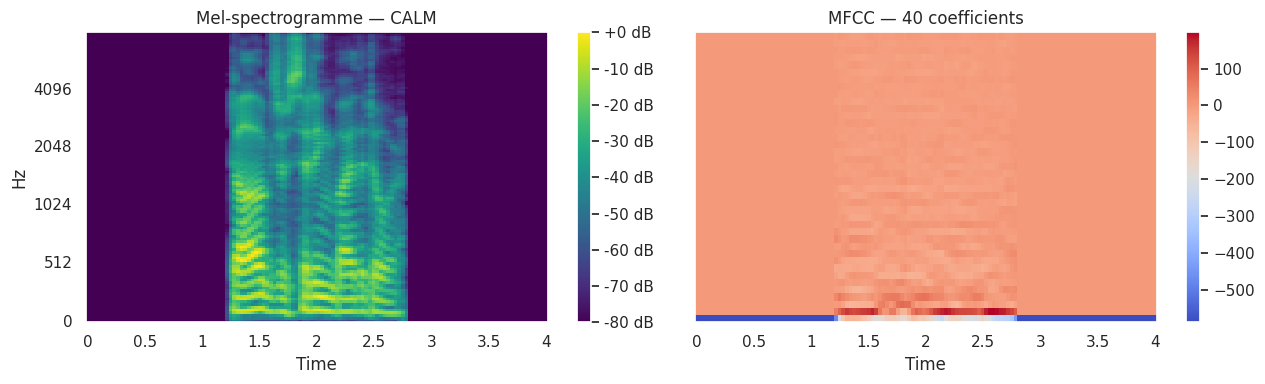

In [25]:
sample      = df.iloc[0]
audio_test  = load_and_fix(sample['path'])
mel_test, mfcc_test = extract_features(audio_test)

print(f'Émotion      : {sample["emotion"]}')
print(f'Audio shape  : {audio_test.shape}')   # (64000,)
print(f'Mel shape    : {mel_test.shape}')      # (128, 126)
print(f'MFCC shape   : {mfcc_test.shape}')    # (40, 126)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
img1 = librosa.display.specshow(mel_test, sr=SR, x_axis='time',
                                 y_axis='mel', ax=axes[0], cmap='viridis')
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')
axes[0].set_title(f"Mel-spectrogramme — {sample['emotion'].upper()}")

img2 = librosa.display.specshow(mfcc_test, sr=SR, x_axis='time',
                                 ax=axes[1], cmap='coolwarm')
fig.colorbar(img2, ax=axes[1])
axes[1].set_title('MFCC — 40 coefficients')

plt.tight_layout()
plt.show()

---
##  Cellule 5 — Fonction d'augmentation + test

In [26]:
def augment_audio(audio, sr=SR):
    """Retourne 3 versions augmentées du signal original."""
    augmented = []

    # 1. Bruit blanc léger
    noise = np.random.randn(len(audio)) * 0.005
    augmented.append(audio + noise)

    # 2. Décalage temporel aléatoire (max 0.5s)
    shift     = np.random.randint(0, sr // 2)
    direction = np.random.choice([-1, 1])
    augmented.append(np.roll(audio, shift * direction))

    # 3. Pitch shift (±2 demi-tons)
    steps = int(np.random.choice([-2, -1, 1, 2]))
    augmented.append(librosa.effects.pitch_shift(audio, sr=sr, n_steps=steps))

    return augmented  # liste de 3 arrays shape (64000,)


# Test rapide
versions = augment_audio(audio_test)
print(f' Augmentation → {len(versions)} variantes | shapes : {[v.shape for v in versions]}')

 Augmentation → 3 variantes | shapes : [(64000,), (64000,), (64000,)]


---
##  Cellule 6 — Extraction complète (originaux + augmentés)
>  Durée estimée : 10–15 min sur Kaggle CPU

In [27]:
all_mels        = []
all_mfccs       = []
all_labels      = []
all_actors      = []
all_is_original = []

print(f'Traitement de {len(df)} fichiers × 4 versions = {len(df)*4} au total...')

for _, row in tqdm(df.iterrows(), total=len(df), desc='Extraction'):
    try:
        audio = load_and_fix(row['path'])
    except Exception as e:
        print(f'  Erreur sur {row["path"]} : {e}')
        continue

    mel, mfcc = extract_features(audio)

    # Original
    all_mels.append(mel)
    all_mfccs.append(mfcc)
    all_labels.append(row['label'])
    all_actors.append(row['actor'])
    all_is_original.append(True)

    # 3 versions augmentées
    for aug_audio in augment_audio(audio):
        aug_mel, aug_mfcc = extract_features(aug_audio)
        all_mels.append(aug_mel)
        all_mfccs.append(aug_mfcc)
        all_labels.append(row['label'])
        all_actors.append(row['actor'])
        all_is_original.append(False)

# Conversion numpy
X_mel       = np.array(all_mels,        dtype=np.float32)
X_mfcc      = np.array(all_mfccs,       dtype=np.float32)
y           = np.array(all_labels,       dtype=np.int64)
actors      = np.array(all_actors,       dtype=np.int64)
is_original = np.array(all_is_original,  dtype=bool)

print(f'\n Extraction terminée !')
print(f'   X_mel  : {X_mel.shape}')    # (N*4, 128, T)
print(f'   X_mfcc : {X_mfcc.shape}')   # (N*4, 40, T)
print(f'   y      : {y.shape}')
print(f'   Originaux : {is_original.sum()} | Total : {len(y)}')

Traitement de 1440 fichiers × 4 versions = 5760 au total...


Extraction:   0%|          | 0/1440 [00:00<?, ?it/s]


 Extraction terminée !
   X_mel  : (5760, 128, 126)
   X_mfcc : (5760, 40, 126)
   y      : (5760,)
   Originaux : 1440 | Total : 5760


---
##  Cellule 7 — Split Train / Val / Test (par acteur)

| Split | Acteurs | Données |
|---|---|---|
| Train | 1 → 16 | originaux + augmentés |
| Val | 17 → 20 | originaux seulement |
| Test | 21 → 24 | originaux seulement |

In [30]:
# Masques
train_mask = (actors <= 16)
val_mask   = (actors > 16) & (actors <= 20) & is_original
test_mask  = (actors > 20) & is_original

X_train, y_train = X_mel[train_mask], y[train_mask]
X_val,   y_val   = X_mel[val_mask],   y[val_mask]
X_test,  y_test  = X_mel[test_mask],  y[test_mask]

total = len(y_train) + len(y_val) + len(y_test)
print('=== Répartition du split ===')
print(f'  Train : {len(y_train):>5} échantillons  ({len(y_train)/total:.0%})')
print(f'  Val   : {len(y_val):>5} échantillons  ({len(y_val)/total:.0%})')
print(f'  Test  : {len(y_test):>5} échantillons  ({len(y_test)/total:.0%})')
print()

# Vérification : toutes les classes présentes dans chaque split
for name, labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    classes = np.unique(labels)
    ok = '✅' if len(classes) == len(LABEL2ID) else '⚠️' 
    print(f'{ok} {name} : {len(classes)}/{len(LABEL2ID)} classes présentes')

=== Répartition du split ===
  Train :  3840 échantillons  (89%)
  Val   :   240 échantillons  (6%)
  Test  :   240 échantillons  (6%)

✅ Train : 8/8 classes présentes
✅ Val : 8/8 classes présentes
✅ Test : 8/8 classes présentes


---
##  Cellule 8 — Sauvegarde des arrays

In [31]:
import os
OUT = '/kaggle/working'

np.save(os.path.join(OUT, 'X_train.npy'), X_train)
np.save(os.path.join(OUT, 'y_train.npy'), y_train)
np.save(os.path.join(OUT, 'X_val.npy'),   X_val)
np.save(os.path.join(OUT, 'y_val.npy'),   y_val)
np.save(os.path.join(OUT, 'X_test.npy'),  X_test)
np.save(os.path.join(OUT, 'y_test.npy'),  y_test)

# Sauvegarder aussi le MFCC complet pour usage futur
np.save(os.path.join(OUT, 'X_mel_all.npy'),  X_mel)
np.save(os.path.join(OUT, 'X_mfcc_all.npy'), X_mfcc)
np.save(os.path.join(OUT, 'y_all.npy'),      y)
np.save(os.path.join(OUT, 'actors_all.npy'), actors)

print(' Fichiers sauvegardés dans /kaggle/working :')
for f in sorted(os.listdir(OUT)):
    if f.endswith('.npy'):
        size = os.path.getsize(os.path.join(OUT, f)) / 1e6
        print(f'   {f:<25} {size:.1f} MB')

 Fichiers sauvegardés dans /kaggle/working :
   X_mel_all.npy             371.6 MB
   X_mfcc_all.npy            116.1 MB
   X_test.npy                15.5 MB
   X_train.npy               247.7 MB
   X_val.npy                 15.5 MB
   actors_all.npy            0.0 MB
   y_all.npy                 0.0 MB
   y_test.npy                0.0 MB
   y_train.npy               0.0 MB
   y_val.npy                 0.0 MB


---
##  Cellule 9 — Vérification visuelle du split

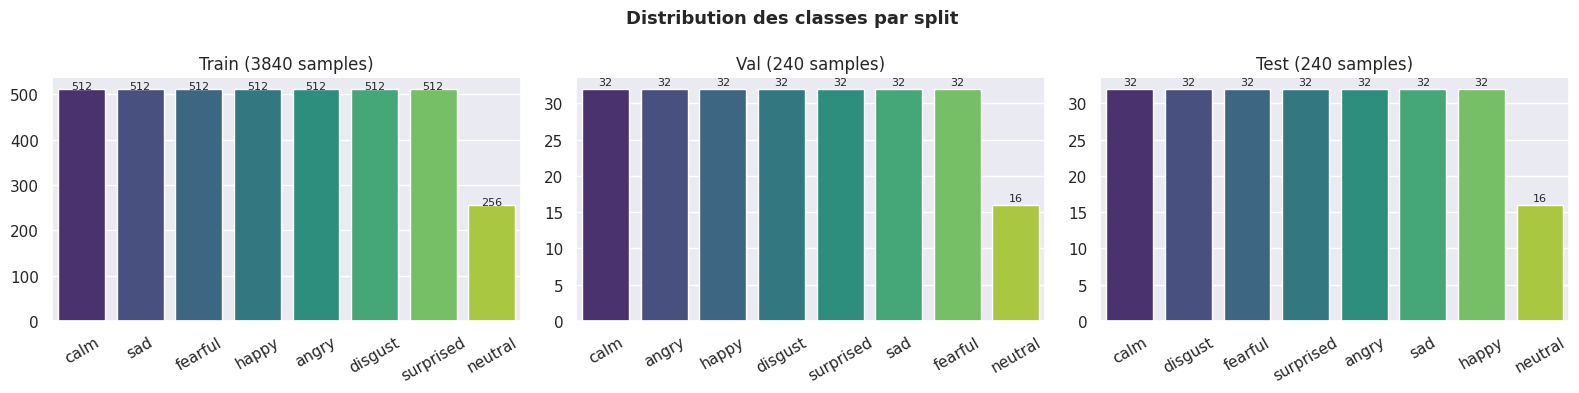

 Sauvegardé : split_distribution.png


In [32]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribution des classes par split', fontsize=13, fontweight='bold')

for ax, (name, labels) in zip(axes, [('Train', y_train), ('Val', y_val), ('Test', y_test)]):
    counts = pd.Series(labels).map(ID2LABEL).value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, hue=counts.index,
                palette='viridis', legend=False)
    ax.set_title(f'{name} ({len(labels)} samples)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                int(bar.get_height()), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'split_distribution.png'), bbox_inches='tight')
plt.show()
print(' Sauvegardé : split_distribution.png')

---
##  Cellule 10 — Résumé final

In [33]:
print('=' * 55)
print('       RÉSUMÉ — TRAITEMENT DES DONNÉES')
print('=' * 55)
print(f'  Sample rate       : {SR} Hz')
print(f'  Durée fixée       : {DURATION}s ({N_SAMPLES} samples)')
print(f'  Mel bands         : {N_MELS}')
print(f'  MFCC coefficients : {N_MFCC}')
print(f'  Augmentation      : x3 (bruit, shift, pitch)')
print(f'  Shape X_train     : {X_train.shape}')
print(f'  Shape X_val       : {X_val.shape}')
print(f'  Shape X_test      : {X_test.shape}')
print('=' * 55)


       RÉSUMÉ — TRAITEMENT DES DONNÉES
  Sample rate       : 16000 Hz
  Durée fixée       : 4.0s (64000 samples)
  Mel bands         : 128
  MFCC coefficients : 40
  Augmentation      : x3 (bruit, shift, pitch)
  Shape X_train     : (3840, 128, 126)
  Shape X_val       : (240, 128, 126)
  Shape X_test      : (240, 128, 126)
